<a href="https://colab.research.google.com/github/Bhavya-48/Student-early-warning-system/blob/main/Student_Warning_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Early Warning and Intervention System
This project uses academic, attendance and engagement data to predict risk and suggest personalised interventions.

### Project Objectives

- Explore and clean student academic data
- Develop a custom early-warning risk scoring system
- Train and compare multiple classification models
- Evaluate model performance using accuracy, precision, recall, F1-score, and confusion matrices
- Identify the key factors contributing to student risk
- Generate personalized intervention recommendations
- Simulate potential interventions using an interactive What-If analysis

In [85]:
import pandas as pd

In [86]:
df = pd.read_csv('/content/dcs_student_data.csv')

In [87]:
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,test_preparation_course,math_score,reading_score,writing_score,science_score
0,S1000,Omar,Williams,student0@university.com,Female,22.0,Engineering,52.29,55.03,57.82,...,74.06,3.99,85.90,56.09,F,1,89,38.0,85.0,26.0
1,S1001,Maria,Brown,student1@university.com,Male,18.0,Engineering,97.27,97.23,45.80,...,94.24,8.32,55.65,50.64,A,0,65,100.0,67.0,96.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24.0,Business,57.19,67.05,93.68,...,85.70,5.05,73.79,70.30,D,0,10,99.0,97.0,58.0
3,S1003,Omar,Williams,student3@university.com,Female,24.0,Mathematics,95.15,47.79,80.63,...,93.51,6.54,92.12,61.63,A,1,22,51.0,41.0,84.0
4,S1004,John,Smith,student4@university.com,Female,23.0,CS,54.18,46.59,78.89,...,83.70,5.97,68.42,66.13,F,1,26,58.0,64.0,65.0


In [88]:
df.shape

(10030, 21)

In [89]:
df.columns

Index(['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age',
       'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
       'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Grade', 'test_preparation_course',
       'math_score', 'reading_score', 'writing_score', 'science_score'],
      dtype='object')

# Exploratory data analysis

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10030 entries, 0 to 10029
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               10030 non-null  object 
 1   First_Name               10030 non-null  object 
 2   Last_Name                10030 non-null  object 
 3   Email                    10030 non-null  object 
 4   Gender                   10030 non-null  object 
 5   Age                      9829 non-null   float64
 6   Department               10030 non-null  object 
 7   Attendance (%)           9831 non-null   float64
 8   Midterm_Score            9828 non-null   float64
 9   Final_Score              9829 non-null   float64
 10  Assignments_Avg          9830 non-null   float64
 11  Quizzes_Avg              9829 non-null   float64
 12  Participation_Score      9828 non-null   float64
 13  Projects_Score           9830 non-null   float64
 14  Total_Score           

In [91]:
df.isnull().sum()

,0
Student_ID,0
First_Name,0
Last_Name,0
Email,0
Gender,0
Age,201
Department,0
Attendance (%),199
Midterm_Score,202
Final_Score,201


In [92]:
df.duplicated().sum()

np.int64(30)

In [93]:
df.describe()

,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,test_preparation_course,reading_score,writing_score,science_score
count,9829.000000,9831.000000,9828.000000,9829.000000,9830.000000,9829.000000,9828.000000,9830.000000,10030.000000,10030.000000,10030.000000,10030.000000,10030.000000
mean,20.780446,75.166073,70.376720,69.830964,74.946202,74.838927,5.014134,75.293326,75.028905,0.387737,70.107674,71.345397,66.073838
std,2.003969,14.440719,17.311362,17.313037,14.362571,14.423340,2.897297,14.438878,14.344126,0.487258,19.062206,18.308729,19.361258
min,-3.000000,-12.000000,-8.000000,-5.000000,50.000000,50.030000,0.000000,50.010000,50.020000,0.000000,17.000000,10.000000,9.000000
25%,19.000000,62.860000,55.440000,54.860000,62.542500,62.360000,2.480000,62.810000,62.832500,0.000000,57.000000,59.000000,53.000000
50%,21.000000,75.320000,70.610000,69.940000,74.920000,74.830000,5.030000,75.415000,75.080000,0.000000,71.000000,72.000000,67.000000
75%,22.000000,87.460000,85.192500,84.820000,87.277500,87.340000,7.530000,87.880000,87.480000,1.000000,85.000000,85.000000,81.000000
max,87.000000,135.000000,145.000000,132.000000,99.980000,99.960000,10.000000,100.000000,99.990000,1.000000,100.000000,100.000000,100.000000


In [94]:
for col in['Gender', 'Department', 'Grade', 'test_preparation_course']:
  print(f"/n{col}:")
  print(df[col].value_counts())

/nGender:
Gender
Male        5018
Female      4832
 FEMALE       90
 MALE         90
Name: count, dtype: int64
/nDepartment:
Department
CS                  3789
Engineering         2830
Business            1927
Mathematics          982
Computer Science     203
 engineering         162
BUSINESS              95
Math                  42
Name: count, dtype: int64
/nGrade:
Grade
A    2969
B    1960
D    1806
F    1658
C    1637
Name: count, dtype: int64
/ntest_preparation_course:
test_preparation_course
0    6141
1    3889
Name: count, dtype: int64


In [95]:
df[['Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score']].corr()['Total_Score'].sort_values(ascending=False)

,Total_Score
Total_Score,1.000000
Assignments_Avg,0.004173
Midterm_Score,0.001107
Quizzes_Avg,0.000009
Final_Score,-0.005289
Attendance (%),-0.010160
Participation_Score,-0.015922
Projects_Score,-0.017102


# Data Cleaning
A separate cleaned dataframe is created while preserving the original dataset.

In [96]:
clean_df = df.copy()

In [97]:
clean_df['Gender'] = clean_df['Gender'].str.strip().str.title()

In [98]:
department_map = {
    'CS': 'Computer Science',
    'Computer Science': 'Computer Science',
    'Engineering': 'Engineering',
    'engineering': 'Engineering',
    'Business': 'Business',
    'BUSINESS': 'Business',
    'Mathematics': 'Mathematics',
    'Math': 'Mathematics'
}
clean_df['Department'] = clean_df['Department'].map(department_map)

In [99]:
score_columns = [
    'Midterm_Score',
    'Final_Score',
    'Assignments_Avg',
    'Quizzes_Avg',
    'Projects_Score',
    'Total_Score',
    'reading_score',
    'writing_score',
    'science_score'
]

for col in score_columns:
    clean_df.loc[
        (clean_df[col] < 0) | (clean_df[col] > 100),
        col
    ] = pd.NA

In [100]:
clean_df.loc[
    (clean_df['Attendance (%)'] < 0) |
    (clean_df['Attendance (%)'] > 100),
    'Attendance (%)'
] = pd.NA

In [101]:
clean_df.loc[
    (clean_df['Age'] < 15) |
    (clean_df['Age'] > 30),
    'Age'
] = pd.NA

In [102]:
numeric_columns = clean_df.select_dtypes(include='number').columns

for col in numeric_columns:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

In [103]:
clean_df = clean_df.drop_duplicates()

In [104]:
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))
print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())

Rows: 10000
Columns: 21
Missing values: 162
Duplicate rows: 0


In [105]:
clean_df.isnull().sum()[clean_df.isnull().sum() > 0]

,0
Department,162


In [106]:
df['Department'].value_counts()

,count
Department,
CS,3789
Engineering,2830
Business,1927
Mathematics,982
Computer Science,203
engineering,162
BUSINESS,95
Math,42


In [107]:
clean_df['Department'] = (
    clean_df['Department']
    .str.strip()
    .str.lower()
    .replace({
        'cs': 'Computer Science',
        'computer science': 'Computer Science',
        'engineering': 'Engineering',
        'business': 'Business',
        'mathematics': 'Mathematics',
        'math': 'Mathematics'
    })
)

In [108]:
clean_df['Department'].value_counts(dropna=False)

,count
Department,
Computer Science,3975
Engineering,2824
Business,2017
Mathematics,1022
NaN,162


In [109]:
clean_df = df.copy()

In [110]:
clean_df['Department'] = (
    clean_df['Department']
    .str.strip()
    .str.lower()
    .replace({
        'cs': 'Computer Science',
        'computer science': 'Computer Science',
        'engineering': 'Engineering',
        'business': 'Business',
        'mathematics': 'Mathematics',
        'math': 'Mathematics'
    })
)

In [111]:
clean_df['Department'].value_counts(dropna=False)

,count
Department,
Computer Science,3992
Engineering,2992
Business,2022
Mathematics,1024


In [112]:
score_columns = [
    'Midterm_Score',
    'Final_Score',
    'Assignments_Avg',
    'Quizzes_Avg',
    'Projects_Score',
    'Total_Score',
    'reading_score',
    'writing_score',
    'science_score'
]

for col in score_columns:
    clean_df.loc[
        (clean_df[col] < 0) | (clean_df[col] > 100),
        col
    ] = pd.NA

In [113]:
clean_df.loc[
    (clean_df['Attendance (%)'] < 0) |
    (clean_df['Attendance (%)'] > 100),
    'Attendance (%)'
] = pd.NA

In [114]:
clean_df.loc[
    (clean_df['Age'] < 15) |
    (clean_df['Age'] > 30),
    'Age'
] = pd.NA

In [115]:
numeric_columns = clean_df.select_dtypes(include='number').columns

for col in numeric_columns:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

In [116]:
clean_df = clean_df.drop_duplicates()

In [117]:
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))
print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())

Rows: 10000
Columns: 21
Missing values: 0
Duplicate rows: 0


### Important graphs

In [118]:
import matplotlib.pyplot as plt

PRIMARY = '#2563EB'
DARK = '#0F172A'
GRID = '#CBD5E1'

def style_graph(title, xlabel, ylabel):
    plt.title(
        title,
        fontsize=16,
        fontweight='bold',
        color=DARK,
        pad=15
    )

    plt.xlabel(xlabel, fontsize=11, color=DARK)
    plt.ylabel(ylabel, fontsize=11, color=DARK)

    plt.grid(
        axis='y',
        linestyle='--',
        linewidth=0.8,
        color=GRID,
        alpha=0.7
    )

    plt.xticks(
        fontsize=11,
        color=DARK
    )

    plt.yticks(
        fontsize=10,
        color=DARK
    )

    plt.gca().set_facecolor('#F8FAFC')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()

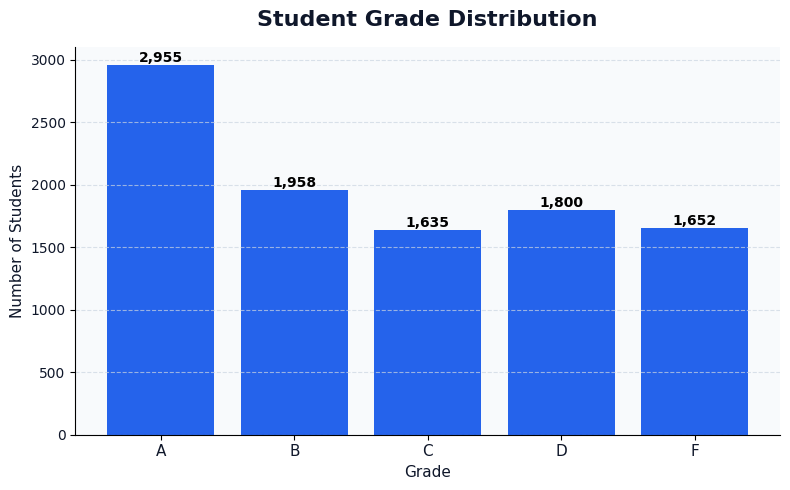

In [119]:
grade_counts = clean_df['Grade'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    grade_counts.index,
    grade_counts.values,
    color = PRIMARY
)

style_graph(
    'Student Grade Distribution',
    'Grade',
    'Number of Students'
)

# Show values above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

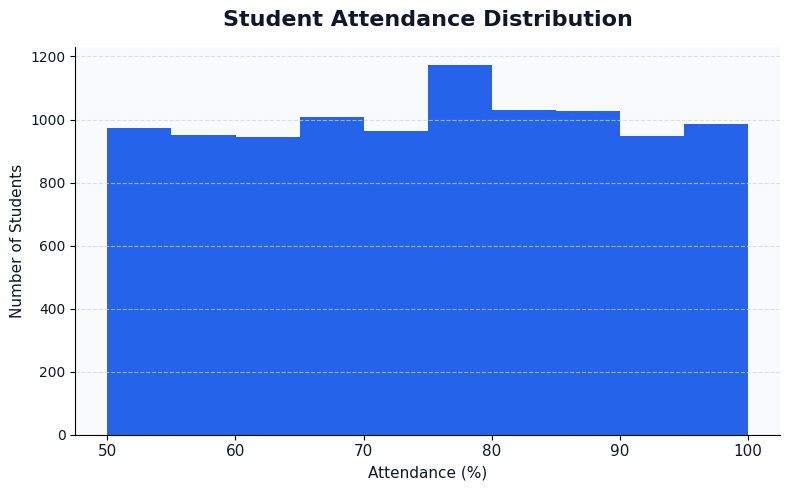

In [120]:
plt.figure(figsize=(8, 5))

plt.hist(
    clean_df['Attendance (%)'],
    bins=10,
    color=PRIMARY
)

style_graph(
    'Student Attendance Distribution',
    'Attendance (%)',
    'Number of Students'
)

plt.show()

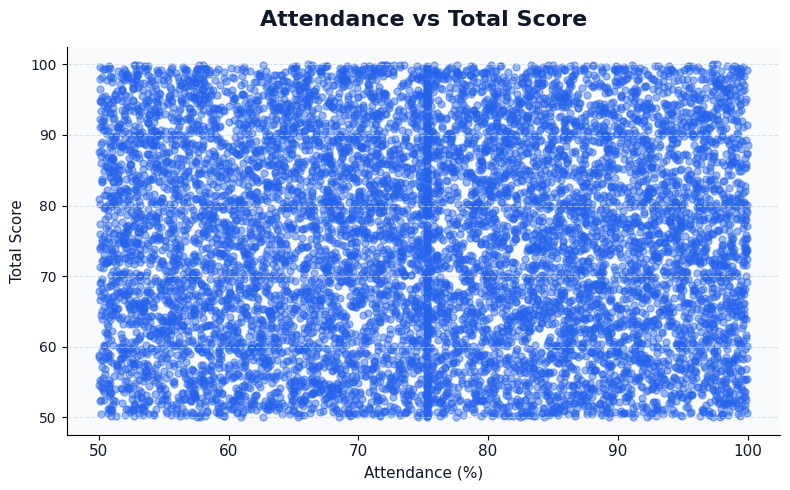

In [121]:
plt.figure(figsize=(8, 5))

plt.scatter(
    clean_df['Attendance (%)'],
    clean_df['Total_Score'],
    color=PRIMARY,
    alpha=0.45,
    s=25
)

style_graph(
    'Attendance vs Total Score',
    'Attendance (%)',
    'Total Score'
)

plt.show()

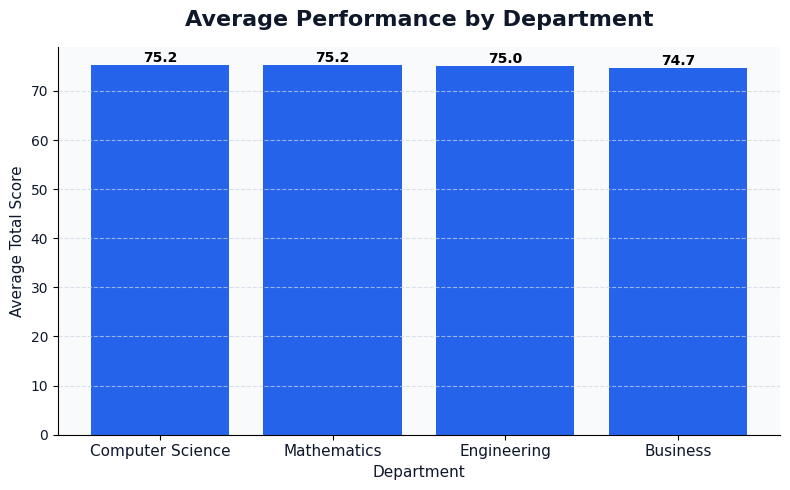

In [122]:
department_scores = (
    clean_df
    .groupby('Department')['Total_Score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    department_scores.index,
    department_scores.values,
    color=PRIMARY
)

style_graph(
    'Average Performance by Department',
    'Department',
    'Average Total Score'
)

# Show average score above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

# Risk Definition

In [123]:
def attendance_points(x):
    if x >= 85:
        return 0
    elif x >= 75:
        return 1
    elif x >= 65:
        return 2
    else:
        return 3


def score_points(x):
    if x >= 75:
        return 0
    elif x >= 60:
        return 1
    elif x >= 45:
        return 2
    else:
        return 3


def participation_points(x):
    if x >= 8:
        return 0
    elif x >= 6:
        return 1
    elif x >= 4:
        return 2
    else:
        return 3


clean_df['Attendance_Points'] = clean_df['Attendance (%)'].apply(attendance_points)

clean_df['Midterm_Points'] = clean_df['Midterm_Score'].apply(score_points)

clean_df['Assignment_Points'] = clean_df['Assignments_Avg'].apply(score_points)

clean_df['Quiz_Points'] = clean_df['Quizzes_Avg'].apply(score_points)

clean_df['Participation_Points'] = clean_df['Participation_Score'].apply(participation_points)


clean_df['Risk_Score'] = (
    clean_df['Attendance_Points']
    + clean_df['Midterm_Points']
    + clean_df['Assignment_Points']
    + clean_df['Quiz_Points']
    + clean_df['Participation_Points']
)


def risk_level(score):
    if score <= 3:
        return 'Low'
    elif score <= 7:
        return 'Medium'
    elif score <= 11:
        return 'High'
    else:
        return 'Critical'


clean_df['Risk_Level'] = clean_df['Risk_Score'].apply(risk_level)

In [124]:
clean_df[['Risk_Score', 'Risk_Level']].head()

,Risk_Score,Risk_Level
0,9,High
1,1,Low
2,7,Medium
3,4,Medium
4,7,Medium


In [125]:
print(clean_df['Risk_Score'].min())
print(clean_df['Risk_Score'].max())
print(clean_df['Risk_Level'].value_counts())

0
13
Risk_Level
Medium      6263
High        2002
Low         1704
Critical      31
Name: count, dtype: int64


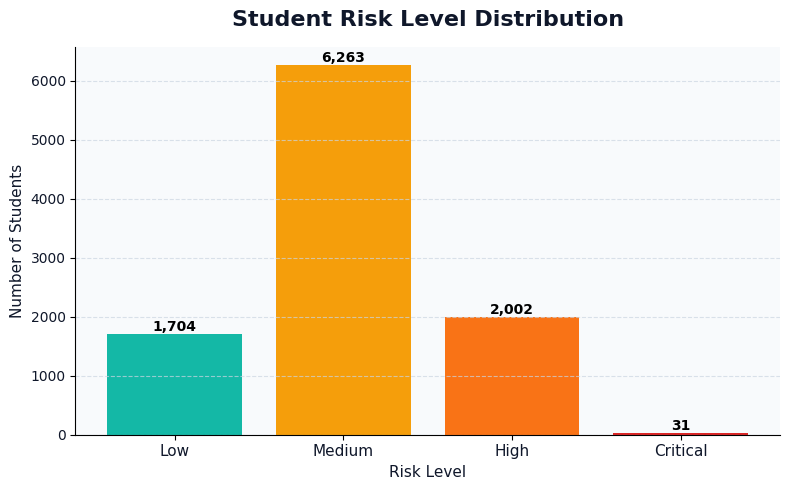

In [126]:
risk_counts = (
    clean_df['Risk_Level']
    .value_counts()
    .reindex(['Low', 'Medium', 'High', 'Critical'])
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    risk_counts.index,
    risk_counts.values,
    color=['#14B8A6', '#F59E0B', '#F97316', '#DC2626']
)

style_graph(
    'Student Risk Level Distribution',
    'Risk Level',
    'Number of Students'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

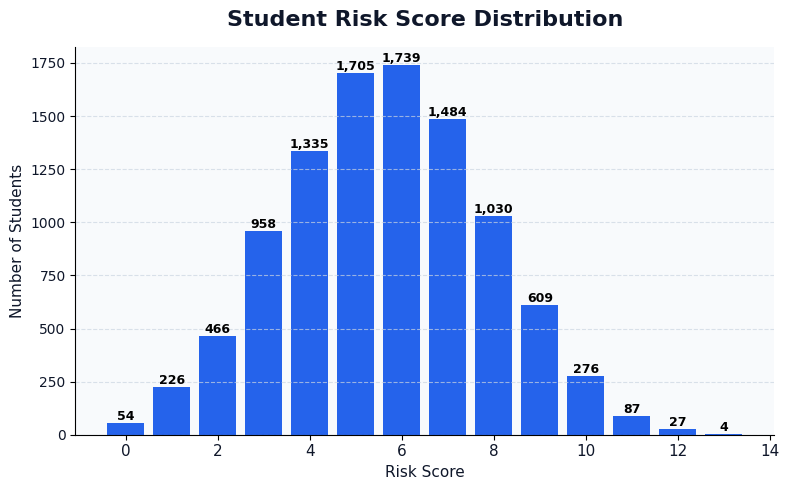

In [127]:
risk_score_counts = (
    clean_df['Risk_Score']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    risk_score_counts.index,
    risk_score_counts.values,
    color=PRIMARY
)

style_graph(
    'Student Risk Score Distribution',
    'Risk Score',
    'Number of Students'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.show()

# Machine Learning
Three classifcation models are trained to predict student risk levels using attendance, assessment performance, and participation indicators.

In [128]:
features = [
    'Attendance (%)',
    'Midterm_Score',
    'Assignments_Avg',
    'Quizzes_Avg',
    'Participation_Score'
]

X = clean_df[features]
y = clean_df['Risk_Level']

print("Features:", features)
print("Target:", y.name)

Features: ['Attendance (%)', 'Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score']
Target: Risk_Level


In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8000
Testing samples: 2000


# Logistic Regression

In [130]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


# Decision Tree

In [131]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


# Random Forest

In [132]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


# Model Evaluation

In [133]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': logistic_pred,
    'Decision Tree': tree_pred,
    'Random Forest': forest_pred
}

results = []

for name, predictions in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, average='weighted'),
        'Recall': recall_score(y_test, predictions, average='weighted'),
        'F1 Score': f1_score(y_test, predictions, average='weighted')
    })

results_df = pd.DataFrame(results)

print(results_df.round(3))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     0.870      0.869   0.870     0.868
1        Decision Tree     0.812      0.808   0.812     0.810
2        Random Forest     0.950      0.951   0.950     0.949


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


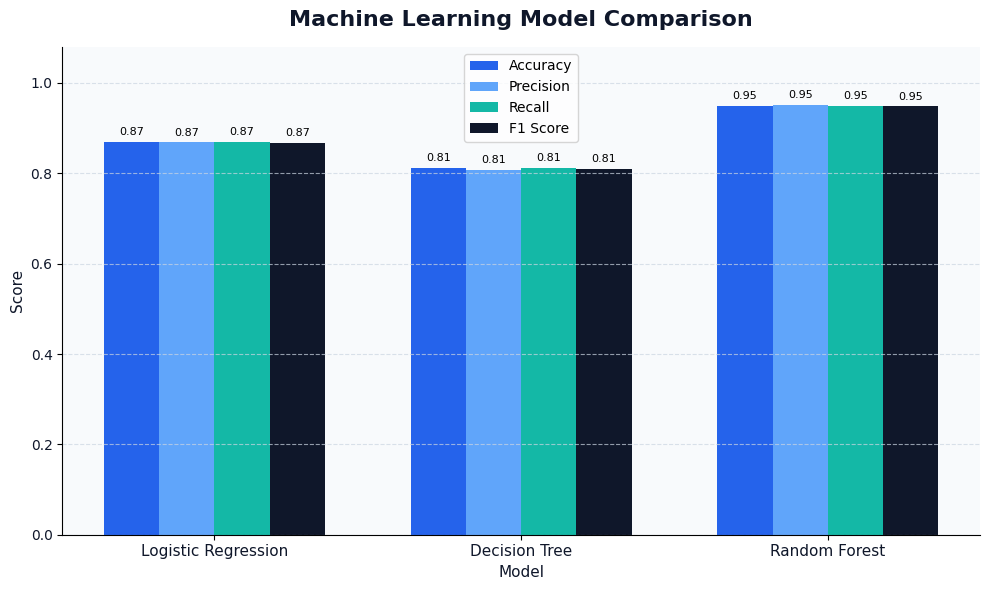

In [134]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

metric_colors = [
    '#2563EB',
    '#60A5FA',
    '#14B8A6',
    '#0F172A'
]

x = range(len(results_df['Model']))
width = 0.18

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metrics):
    bars = plt.bar(
        [pos + (i - 1.5) * width for pos in x],
        results_df[metric],
        width=width,
        label=metric,
        color=metric_colors[i]
    )

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.xticks(
    list(x),
    results_df['Model'],
    fontsize=10
)

style_graph(
    'Machine Learning Model Comparison',
    'Model',
    'Score'
)

plt.ylim(0, 1.08)
plt.legend()

plt.show()

# Confusion Matrix for Random Forest

<Figure size 700x600 with 0 Axes>

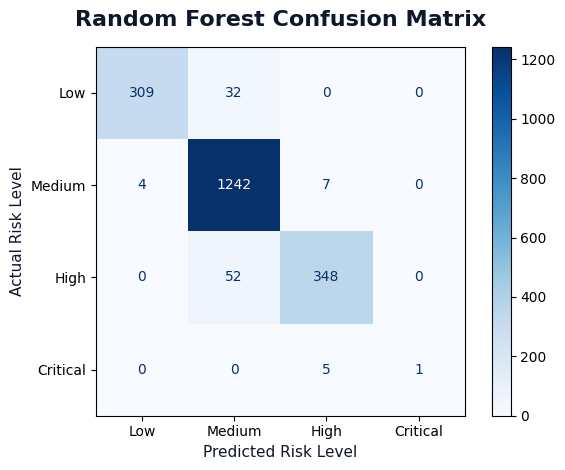

In [135]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    forest_pred,
    labels=['Low', 'Medium', 'High', 'Critical']
)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Medium', 'High', 'Critical']
)

disp.plot(
    cmap='Blues',
    values_format='d'
)

plt.title(
    'Random Forest Confusion Matrix',
    fontsize=16,
    fontweight='bold',
    color=DARK,
    pad=15
)

plt.xlabel('Predicted Risk Level', fontsize=11, color=DARK)
plt.ylabel('Actual Risk Level', fontsize=11, color=DARK)

plt.tight_layout()
plt.show()

In [136]:
print(cm)

[[ 309   32    0    0]
 [   4 1242    7    0]
 [   0   52  348    0]
 [   0    0    5    1]]


In [137]:
from sklearn.ensemble import RandomForestClassifier

balanced_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

balanced_forest.fit(X_train, y_train)

balanced_forest_pred = balanced_forest.predict(X_test)

print("Balanced Random Forest trained successfully!")

Balanced Random Forest trained successfully!


In [138]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    balanced_forest_pred,
    labels=['Low', 'Medium', 'High', 'Critical'],
    zero_division=0
))

              precision    recall  f1-score   support

         Low       0.88      0.97      0.92       341
      Medium       0.98      0.92      0.95      1253
        High       0.88      0.95      0.91       400
    Critical       0.75      0.50      0.60         6

    accuracy                           0.94      2000
   macro avg       0.87      0.84      0.85      2000
weighted avg       0.94      0.94      0.94      2000



<Figure size 700x600 with 0 Axes>

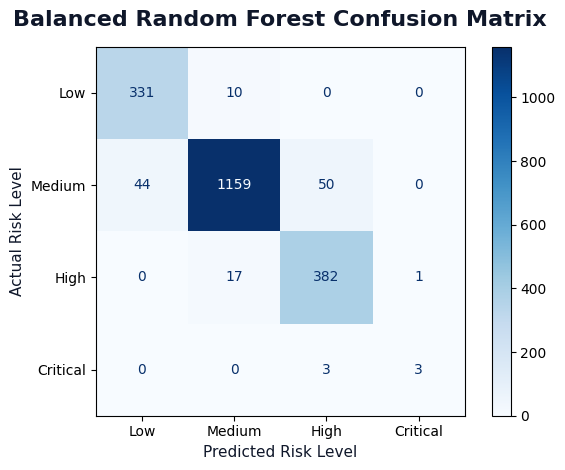

In [139]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_balanced = confusion_matrix(
    y_test,
    balanced_forest_pred,
    labels=['Low', 'Medium', 'High', 'Critical']
)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=['Low', 'Medium', 'High', 'Critical']
)

disp.plot(
    cmap='Blues',
    values_format='d'
)

plt.title(
    'Balanced Random Forest Confusion Matrix',
    fontsize=16,
    fontweight='bold',
    color=DARK,
    pad=15
)

plt.xlabel(
    'Predicted Risk Level',
    fontsize=11,
    color=DARK
)

plt.ylabel(
    'Actual Risk Level',
    fontsize=11,
    color=DARK
)

plt.tight_layout()
plt.show()

In [140]:
print(cm_balanced)

[[ 331   10    0    0]
 [  44 1159   50    0]
 [   0   17  382    1]
 [   0    0    3    3]]


## Model Evaluation — Conclusion

Among the three models evaluated, Random Forest initially achieved the highest overall accuracy of 95%. However, the initial model showed poor detection of the rare Critical-risk class due to class imbalance.

To address this, a class-balanced Random Forest was trained. Although its overall accuracy decreased slightly to 94%, Critical-risk recall improved from approximately 17% to 50%. The model also maintained strong recall for Low (97%), Medium (92%), and High (95.5%) risk students.

Since this is an early-warning system, identifying students who may require urgent intervention is more important than maximizing overall accuracy alone. Therefore, the class-balanced Random Forest was selected as the final model.

A key limitation is that the Critical class contains very few students, so its performance should be interpreted cautiously.

In [141]:
risk_factor_columns = {
    'Attendance (%)': 'Attendance_Points',
    'Midterm_Score': 'Midterm_Points',
    'Assignments_Avg': 'Assignment_Points',
    'Quizzes_Avg': 'Quiz_Points',
    'Participation_Score': 'Participation_Points'
}

print("Risk factors defined successfully!")

Risk factors defined successfully!


In [142]:
# Select one high-risk student as an example
example_student = clean_df[
    clean_df['Risk_Level'] == 'High'
].iloc[0]

print("Student ID:", example_student['Student_ID'])
print("Risk Score:", example_student['Risk_Score'], "/ 15")
print("Risk Level:", example_student['Risk_Level'])
print("\nRisk Factors:")

for feature, points_column in risk_factor_columns.items():
    print(
        feature,
        "=", example_student[feature],
        "→",
        example_student[points_column],
        "risk points"
    )

Student ID: S1000
Risk Score: 9 / 15
Risk Level: High

Risk Factors:
Attendance (%) = 52.29 → 3 risk points
Midterm_Score = 55.03 → 2 risk points
Assignments_Avg = 84.22 → 0 risk points
Quizzes_Avg = 74.06 → 1 risk points
Participation_Score = 3.99 → 3 risk points


In [143]:
# Find the main risk factors for the example student

factor_scores = {
    feature: example_student[points_column]
    for feature, points_column in risk_factor_columns.items()
}

max_points = max(factor_scores.values())

main_risk_factors = [
    feature
    for feature, points in factor_scores.items()
    if points == max_points
]

print("Main Risk Factors:")

for factor in main_risk_factors:
    print("-", factor)

Main Risk Factors:
- Attendance (%)
- Participation_Score


In [144]:
def generate_recommendations(student):
    recommendations = []

    if student['Attendance_Points'] >= 2:
        recommendations.append(
            "Improve attendance and maintain more consistent class participation."
        )

    if student['Midterm_Points'] >= 2:
        recommendations.append(
            "Focus on midterm revision and strengthen weaker academic topics."
        )

    if student['Assignment_Points'] >= 2:
        recommendations.append(
            "Follow a regular assignment schedule and seek support for difficult topics."
        )

    if student['Quiz_Points'] >= 2:
        recommendations.append(
            "Practice regularly with short quizzes to improve consistency."
        )

    if student['Participation_Points'] >= 2:
        recommendations.append(
            "Increase class participation and stay actively engaged during sessions."
        )

    if not recommendations:
        recommendations.append(
            "Maintain the current study routine and continue monitoring performance."
        )

    return recommendations

In [145]:
recommendations = generate_recommendations(example_student)

print("Recommended Interventions:")

for recommendation in recommendations:
    print("-", recommendation)

Recommended Interventions:
- Improve attendance and maintain more consistent class participation.
- Focus on midterm revision and strengthen weaker academic topics.
- Increase class participation and stay actively engaged during sessions.


### Report Generation

In [146]:
from IPython.display import display, HTML

def generate_student_report(student_id):

    # Find student
    student_data = clean_df[
        clean_df['Student_ID'] == student_id
    ]

    if student_data.empty:
        display(HTML(f"""
        <div style="
            padding:20px;
            border-radius:12px;
            background:#FEF2F2;
            border:1px solid #FECACA;
            color:#991B1B;
            font-family:Arial,sans-serif;
        ">
            <b>Student not found</b><br>
            No student with ID <b>{student_id}</b> exists in the dataset.
        </div>
        """))
        return

    student = student_data.iloc[0]

    # Risk colors
    risk_colors = {
        'Low': '#14B8A6',
        'Medium': '#F59E0B',
        'High': '#F97316',
        'Critical': '#DC2626'
    }

    risk_color = risk_colors[student['Risk_Level']]

    # Risk factors
    factor_scores = {
        feature: student[points_column]
        for feature, points_column in risk_factor_columns.items()
    }

    max_points = max(factor_scores.values())

    main_risk_factors = [
        feature
        for feature, points in factor_scores.items()
        if points == max_points and points > 0
    ]

    # Recommendations
    recommendations = generate_recommendations(student)

    # Build risk factor rows
    factor_rows = ""

    for feature, points_column in risk_factor_columns.items():

        value = student[feature]
        points = student[points_column]

        if points == 0:
            point_color = '#14B8A6'
        elif points == 1:
            point_color = '#F59E0B'
        else:
            point_color = '#DC2626'

        factor_rows += f"""
        <tr>
            <td>{feature}</td>
            <td>{value:.2f}</td>
            <td>
                <span style="
                    background:{point_color};
                    color:white;
                    padding:4px 10px;
                    border-radius:20px;
                    font-weight:bold;
                ">
                    +{points}
                </span>
            </td>
        </tr>
        """

    # Main risk factor list
    main_factors_html = ""

    for factor in main_risk_factors:
        main_factors_html += f"""
        <div style="
            background:#FFF7ED;
            border-left:4px solid #F97316;
            padding:10px 14px;
            margin:6px 0;
            border-radius:6px;
            color:#0F172A;
        ">
            ⚠️ <b>{factor}</b>
        </div>
        """

    if not main_factors_html:
        main_factors_html = """
        <div style="
            background:#ECFDF5;
            padding:12px;
            border-radius:8px;
            color:#065F46;
        ">
            ✓ No major risk factors identified.
        </div>
        """

    # Recommendation list
    recommendations_html = ""

    for recommendation in recommendations:
        recommendations_html += f"""
        <div style="
            padding:9px 0;
            color:#0F172A;
        ">
            <span style="color:#2563EB;font-weight:bold;">→</span>
            {recommendation}
        </div>
        """

    # Final report
    report = f"""
    <div style="
        max-width:850px;
        margin:20px auto;
        font-family:Arial,sans-serif;
        color:#0F172A;
        background:#F8FAFC;
        border:1px solid #CBD5E1;
        border-radius:18px;
        overflow:hidden;
        box-shadow:0 6px 20px rgba(15,23,42,0.08);
    ">

        <!-- Header -->
        <div style="
            background:#0F172A;
            padding:24px 28px;
            color:white;
        ">
            <div style="
                font-size:13px;
                letter-spacing:2px;
                color:#94A3B8;
                font-weight:bold;
            ">
                STUDENT EARLY-WARNING SYSTEM
            </div>

            <div style="
                font-size:27px;
                font-weight:bold;
                margin-top:6px;
            ">
                Student Risk Report
            </div>

            <div style="
                margin-top:6px;
                color:#CBD5E1;
            ">
                Student ID: {student['Student_ID']}
            </div>
        </div>

        <!-- Risk Summary -->
        <div style="
            display:flex;
            gap:16px;
            padding:24px 28px;
            background:white;
            flex-wrap:wrap;
        ">

            <div style="
                flex:1;
                min-width:180px;
                padding:18px;
                border-radius:12px;
                background:#F8FAFC;
                border:1px solid #E2E8F0;
            ">
                <div style="font-size:13px;color:#64748B;">
                    RISK SCORE
                </div>

                <div style="
                    font-size:30px;
                    font-weight:bold;
                    color:#2563EB;
                    margin-top:5px;
                ">
                    {student['Risk_Score']} / 15
                </div>
            </div>

            <div style="
                flex:1;
                min-width:180px;
                padding:18px;
                border-radius:12px;
                background:#F8FAFC;
                border:1px solid #E2E8F0;
            ">
                <div style="font-size:13px;color:#64748B;">
                    RISK LEVEL
                </div>

                <div style="
                    display:inline-block;
                    margin-top:8px;
                    padding:7px 16px;
                    border-radius:20px;
                    background:{risk_color};
                    color:white;
                    font-size:16px;
                    font-weight:bold;
                ">
                    {student['Risk_Level'].upper()}
                </div>
            </div>

        </div>

        <!-- Risk Breakdown -->
        <div style="
            padding:24px 28px;
        ">

            <h3 style="
                color:#0F172A;
                margin-bottom:14px;
            ">
                Risk Breakdown
            </h3>

            <table style="
                width:100%;
                border-collapse:collapse;
                background:white;
                border-radius:10px;
                overflow:hidden;
            ">

                <tr style="
                    background:#EFF6FF;
                    color:#0F172A;
                ">
                    <th style="padding:12px;text-align:left;">Factor</th>
                    <th style="padding:12px;text-align:left;">Value</th>
                    <th style="padding:12px;text-align:left;">Risk Points</th>
                </tr>

                {factor_rows}

            </table>
        </div>

        <!-- Main Risk Factors -->
        <div style="
            padding:0 28px 24px 28px;
        ">

            <h3 style="color:#0F172A;">
                Main Risk Factors
            </h3>

            {main_factors_html}

        </div>

        <!-- Recommendations -->
        <div style="
            margin:0 28px 28px 28px;
            padding:20px;
            background:#EFF6FF;
            border-radius:12px;
            border:1px solid #BFDBFE;
        ">

            <h3 style="
                margin-top:0;
                color:#0F172A;
            ">
                Recommended Interventions
            </h3>

            {recommendations_html}

        </div>

    </div>
    """

    display(HTML(report))

## What-If Risk Simulator

This section allows us to simulate how changes in a student's academic and engagement indicators could affect their overall risk level. By adjusting attendance, assessment scores, assignment performance, quiz performance, and participation, we can compare the student's current risk with a simulated scenario and identify potential improvements.

In [147]:
def calculate_risk_score(attendance, midterm, assignments, quizzes, participation):

    attendance_risk = attendance_points(attendance)
    midterm_risk = score_points(midterm)
    assignment_risk = score_points(assignments)
    quiz_risk = score_points(quizzes)
    participation_risk = participation_points(participation)

    total_risk = (
        attendance_risk
        + midterm_risk
        + assignment_risk
        + quiz_risk
        + participation_risk
    )

    level = risk_level(total_risk)

    return total_risk, level

In [148]:
student = clean_df[clean_df['Student_ID'] == 'S1000'].iloc[0]

current_score, current_level = calculate_risk_score(
    student['Attendance (%)'],
    student['Midterm_Score'],
    student['Assignments_Avg'],
    student['Quizzes_Avg'],
    student['Participation_Score']
)

print("Current Risk Score:", current_score, "/ 15")
print("Current Risk Level:", current_level)

Current Risk Score: 9 / 15
Current Risk Level: High


In [149]:
what_if_score, what_if_level = calculate_risk_score(
    75,       # Attendance
    60,       # Midterm
    84.22,    # Assignments
    75,       # Quizzes
    6         # Participation
)

print("What-If Risk Score:", what_if_score, "/ 15")
print("What-If Risk Level:", what_if_level)

What-If Risk Score: 3 / 15
What-If Risk Level: Low


In [150]:
def compare_risk(current_score, current_level, what_if_score, what_if_level):

    difference = current_score - what_if_score

    print("CURRENT RISK")
    print(f"Score: {current_score} / 15")
    print(f"Level: {current_level}")

    print("\nWHAT-IF RISK")
    print(f"Score: {what_if_score} / 15")
    print(f"Level: {what_if_level}")

    print("\nRISK CHANGE")
    print(f"Risk reduced by: {difference} points")

In [151]:
compare_risk(
    current_score,
    current_level,
    what_if_score,
    what_if_level
)

CURRENT RISK
Score: 9 / 15
Level: High

WHAT-IF RISK
Score: 3 / 15
Level: Low

RISK CHANGE
Risk reduced by: 6 points


In [152]:
from IPython.display import display, HTML

def generate_what_if_report(
    student_id,
    current_score,
    current_level,
    what_if_score,
    what_if_level
):

    risk_colors = {
        'Low': '#14B8A6',
        'Medium': '#F59E0B',
        'High': '#F97316',
        'Critical': '#DC2626'
    }

    current_color = risk_colors[current_level]
    what_if_color = risk_colors[what_if_level]

    difference = current_score - what_if_score

    if difference > 0:
        change_text = f"↓ {difference} risk points"
        change_color = '#14B8A6'
        change_message = "Potential improvement"
    elif difference < 0:
        change_text = f"↑ {abs(difference)} risk points"
        change_color = '#DC2626'
        change_message = "Risk increased"
    else:
        change_text = "No change"
        change_color = '#64748B'
        change_message = "Risk remains unchanged"

    report = f"""
    <div style="
        width: 100%;
        max-width: none;
        margin:0;
        box-sizing:border-box;
        font-family:Arial,sans-serif;
        color:#0F172A;
        background:#F8FAFC;
        border:1px solid #CBD5E1;
        border-radius:16px;
        overflow:hidden;
        box-shadow:0 4px 14px rgba(15,23,42,0.07);
    ">

        <!-- Compact Header -->
        <div style="
            background:#0F172A;
            padding:18px 24px;
            color:white;
            display:flex;
            justify-content:space-between;
            align-items:center;
            gap:12px;
            flex-wrap:wrap;
        ">

            <div>
                <div style="
                    font-size:11px;
                    letter-spacing:1.8px;
                    color:#94A3B8;
                    font-weight:bold;
                ">
                    WHAT-IF RISK SIMULATOR
                </div>

                <div style="
                    font-size:22px;
                    font-weight:bold;
                    margin-top:4px;
                ">
                    Intervention Simulation
                </div>
            </div>

            <div style="
                background:#1E293B;
                padding:7px 12px;
                border-radius:8px;
                font-size:12px;
                color:#CBD5E1;
                white-space:nowrap;
            ">
                Student <b style="color:white;">{student_id}</b>
            </div>

        </div>

        <!-- Comparison -->
        <div style="
            padding:20px 24px 16px;
            display:flex;
            align-items:stretch;
            gap:12px;
            background:white;
        ">

            <!-- Current -->
            <div style="
                flex:1 1 0;
                min-width:0;
                padding:16px;
                border-radius:12px;
                background:#F8FAFC;
                border:1px solid #E2E8F0;
            ">

                <div style="
                    font-size:11px;
                    font-weight:bold;
                    letter-spacing:1px;
                    color:#64748B;
                ">
                    CURRENT
                </div>

                <div style="
                    font-size:28px;
                    font-weight:bold;
                    margin-top:5px;
                    color:#0F172A;
                ">
                    {current_score}<span style="
                        font-size:14px;
                        color:#94A3B8;
                    ">/15</span>
                </div>

                <span style="
                    display:inline-block;
                    margin-top:5px;
                    padding:4px 11px;
                    border-radius:20px;
                    background:{current_color};
                    color:white;
                    font-size:12px;
                    font-weight:bold;
                ">
                    {current_level.upper()}
                </span>

            </div>

            <!-- Arrow -->
            <div style="
                display:flex;
                align-items:center;
                justify-content:center;
                color:#2563EB;
                font-size:22px;
                font-weight:bold;
                width:28px;
            ">
                →
            </div>

            <!-- What-if -->
            <div style="
                flex:1;
                padding:16px;
                border-radius:12px;
                background:#EFF6FF;
                border:1px solid #BFDBFE;
            ">

                <div style="
                    font-size:11px;
                    font-weight:bold;
                    letter-spacing:1px;
                    color:#2563EB;
                ">
                    WHAT-IF
                </div>

                <div style="
                    font-size:28px;
                    font-weight:bold;
                    margin-top:5px;
                    color:#2563EB;
                ">
                    {what_if_score}<span style="
                        font-size:14px;
                        color:#64748B;
                    ">/15</span>
                </div>

                <span style="
                    display:inline-block;
                    margin-top:5px;
                    padding:4px 11px;
                    border-radius:20px;
                    background:{what_if_color};
                    color:white;
                    font-size:12px;
                    font-weight:bold;
                ">
                    {what_if_level.upper()}
                </span>

            </div>

        </div>

        <!-- Result -->
        <div style="
            margin:0 24px 20px;
            padding:13px 16px;
            border-radius:10px;
            background:#ECFDF5;
            border:1px solid #A7F3D0;
            display:flex;
            align-items:center;
            justify-content:space-between;
            gap:12px;
        ">

            <div>
                <div style="
                    font-size:12px;
                    color:#64748B;
                ">
                    SIMULATION RESULT
                </div>

                <div style="
                    font-size:17px;
                    font-weight:bold;
                    color:{change_color};
                    margin-top:2px;
                ">
                    {change_message}
                </div>
            </div>

            <div style="
                font-size:20px;
                font-weight:bold;
                color:{change_color};
            ">
                {change_text}
            </div>

        </div>

        <div style="
            text-align:center;
            padding:0 20px 16px;
            font-size:11px;
            color:#94A3B8;
        ">
            Based on the defined early-warning risk criteria.
        </div>

    </div>
    """

    display(HTML(report))

In [153]:
def run_what_if_simulation(
    student_id,
    attendance,
    midterm,
    assignments,
    quizzes,
    participation
):

    student_data = clean_df[
        clean_df['Student_ID'] == student_id
    ]

    if student_data.empty:
        print(f"Student ID '{student_id}' not found.")
        return

    student = student_data.iloc[0]

    # Current risk
    current_score, current_level = calculate_risk_score(
        student['Attendance (%)'],
        student['Midterm_Score'],
        student['Assignments_Avg'],
        student['Quizzes_Avg'],
        student['Participation_Score']
    )

    # Simulated risk
    what_if_score, what_if_level = calculate_risk_score(
        attendance,
        midterm,
        assignments,
        quizzes,
        participation
    )

    # Display polished comparison
    generate_what_if_report(
        student_id,
        current_score,
        current_level,
        what_if_score,
        what_if_level
    )

In [154]:
run_what_if_simulation(
    student_id='S1000',
    attendance=75,
    midterm=60,
    assignments=84.22,
    quizzes=75,
    participation=6
)

In [155]:
import ipywidgets as widgets
from IPython.display import display

student_id = 'S1000'

attendance_slider = widgets.FloatSlider(
    value=75,
    min=0,
    max=100,
    step=1,
    description='Attendance:',
    continuous_update=False
)

midterm_slider = widgets.FloatSlider(
    value=60,
    min=0,
    max=100,
    step=1,
    description='Midterm:',
    continuous_update=False
)

assignment_slider = widgets.FloatSlider(
    value=84,
    min=0,
    max=100,
    step=1,
    description='Assignments:',
    continuous_update=False
)

quiz_slider = widgets.FloatSlider(
    value=75,
    min=0,
    max=100,
    step=1,
    description='Quizzes:',
    continuous_update=False
)

participation_slider = widgets.FloatSlider(
    value=6,
    min=0,
    max=10,
    step=1,
    description='Participation:',
    continuous_update=False
)

display(
    attendance_slider,
    midterm_slider,
    assignment_slider,
    quiz_slider,
    participation_slider
)

FloatSlider(value=75.0, continuous_update=False, description='Attendance:', step=1.0)

FloatSlider(value=60.0, continuous_update=False, description='Midterm:', step=1.0)

FloatSlider(value=84.0, continuous_update=False, description='Assignments:', step=1.0)

FloatSlider(value=75.0, continuous_update=False, description='Quizzes:', step=1.0)

FloatSlider(value=6.0, continuous_update=False, description='Participation:', max=10.0, step=1.0)

In [156]:
# Make sliders responsive instead of fixed at 500px

for slider in [
    attendance_slider,
    midterm_slider,
    assignment_slider,
    quiz_slider,
    participation_slider
]:
    slider.layout = widgets.Layout(width='100%')

In [157]:
def update_simulation(change=None):

    run_what_if_simulation(
        student_id=student_id,
        attendance=attendance_slider.value,
        midterm=midterm_slider.value,
        assignments=assignment_slider.value,
        quizzes=quiz_slider.value,
        participation=participation_slider.value
    )


# Update the report whenever a slider changes
for slider in [
    attendance_slider,
    midterm_slider,
    assignment_slider,
    quiz_slider,
    participation_slider
]:
    slider.observe(update_simulation, names='value')


# Show the initial result
update_simulation()

In [158]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# Enable widgets in Google Colab
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except:
    pass


# STUDENT SELECTOR

student_dropdown = widgets.Dropdown(
    options=clean_df['Student_ID'].tolist(),
    value='S1000',
    description='Student:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='280px')
)


# SLIDERS

def create_slider(description, value, max_value):
    return widgets.FloatSlider(
        value=value,
        min=0,
        max=max_value,
        step=1,
        description=description,
        continuous_update=False,
        style={'description_width': '110px'},
        layout=widgets.Layout(width='100%')
    )


attendance_slider = create_slider(
    'Attendance', 75, 100
)

midterm_slider = create_slider(
    'Midterm', 60, 100
)

assignment_slider = create_slider(
    'Assignments', 84, 100
)

quiz_slider = create_slider(
    'Quizzes', 75, 100
)

participation_slider = create_slider(
    'Participation', 6, 10
)


# OUTPUT AREA

simulation_output = widgets.Output()


# UPDATE SIMULATION

def update_simulation(change=None):

    student_id = student_dropdown.value

    student_data = clean_df[
        clean_df['Student_ID'] == student_id
    ]

    if student_data.empty:
        return

    student = student_data.iloc[0]

    # Calculate current risk
    current_score, current_level = calculate_risk_score(
        student['Attendance (%)'],
        student['Midterm_Score'],
        student['Assignments_Avg'],
        student['Quizzes_Avg'],
        student['Participation_Score']
    )

    # Calculate what-if risk
    what_if_score, what_if_level = calculate_risk_score(
        attendance_slider.value,
        midterm_slider.value,
        assignment_slider.value,
        quiz_slider.value,
        participation_slider.value
    )

    # Update report
    with simulation_output:

        clear_output(wait=True)

        generate_what_if_report(
            student_id=student_id,
            current_score=current_score,
            current_level=current_level,
            what_if_score=what_if_score,
            what_if_level=what_if_level
        )


# UPDATE SLIDERS WHEN STUDENT CHANGES

def load_student_values(change=None):

    student_id = student_dropdown.value

    student = clean_df[
        clean_df['Student_ID'] == student_id
    ].iloc[0]

    attendance_slider.value = round(student['Attendance (%)'])
    midterm_slider.value = round(student['Midterm_Score'])
    assignment_slider.value = round(student['Assignments_Avg'])
    quiz_slider.value = round(student['Quizzes_Avg'])
    participation_slider.value = round(student['Participation_Score'])

    update_simulation()


# CONNECT EVENTS


student_dropdown.observe(
    load_student_values,
    names='value'
)

for slider in [
    attendance_slider,
    midterm_slider,
    assignment_slider,
    quiz_slider,
    participation_slider
]:

    slider.observe(
        update_simulation,
        names='value'
    )


# STYLING / LAYOUT

controls_title = widgets.HTML(
    """
    <div style="
        font-family:Arial,sans-serif;
        color:#0F172A;
        margin-bottom:10px;
    ">
        <div style="
            font-size:12px;
            letter-spacing:1.5px;
            font-weight:bold;
            color:#64748B;
        ">
            SIMULATE INTERVENTION
        </div>

        <div style="
            font-size:21px;
            font-weight:bold;
            margin-top:4px;
        ">
            Adjust Student Factors
        </div>

        <div style="
            font-size:12px;
            color:#64748B;
            margin-top:5px;
        ">
            Move the sliders to see how risk changes.
        </div>
    </div>
    """
)


student_box = widgets.HBox(
    [student_dropdown],
    layout=widgets.Layout(
        justify_content='flex-start',
        margin='0 0 14px 0'
    )
)


controls = widgets.VBox(
    [
        controls_title,
        student_box,
        attendance_slider,
        midterm_slider,
        assignment_slider,
        quiz_slider,
        participation_slider
    ],
    layout=widgets.Layout(
        width='48%',
        padding='22px',
        border='1px solid #CBD5E1',
        border_radius='14px',
        background_color='#F8FAFC'
    )
)


report_box = widgets.VBox(
    [
        simulation_output
    ],
    layout=widgets.Layout(
        width='52%',
        padding='0 0 0 16px'
    )
)


dashboard = widgets.HBox(
    [
        controls,
        report_box
    ],
    layout=widgets.Layout(
        width='100%',
        align_items='flex-start'
    )
)


# Display
display(dashboard)

# Initial report
load_student_values()

In [159]:
def get_intervention_changes(
    current_attendance,
    current_midterm,
    current_assignments,
    current_quizzes,
    current_participation,
    new_attendance,
    new_midterm,
    new_assignments,
    new_quizzes,
    new_participation
):

    changes = []

    values = [
        ('Attendance', current_attendance, new_attendance, '%'),
        ('Midterm', current_midterm, new_midterm, ''),
        ('Assignments', current_assignments, new_assignments, ''),
        ('Quizzes', current_quizzes, new_quizzes, ''),
        ('Participation', current_participation, new_participation, '')
    ]

    for name, old, new, unit in values:

        difference = new - old

        if abs(difference) >= 0.01:

            if difference > 0:
                changes.append(
                    f"{name}: {old:.0f}{unit} → {new:.0f}{unit} "
                    f"(+{difference:.0f}{unit})"
                )
            else:
                changes.append(
                    f"{name}: {old:.0f}{unit} → {new:.0f}{unit} "
                    f"({difference:.0f}{unit})"
                )

    return changes

In [160]:
changes = get_intervention_changes(
    65, 81, 65, 69, 6,
    85, 81, 65, 69, 8
)

for change in changes:
    print(change)

Attendance: 65% → 85% (+20%)
Participation: 6 → 8 (+2)


In [161]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Enable widgets in Google Colab
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except:
    pass


# STUDENT INPUT

student_input = widgets.Text(
    value='S1000',
    placeholder='Enter Student ID',
    description='Student ID:',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='300px')
)

generate_button = widgets.Button(
    description='Generate Report',
    button_style='primary',
    layout=widgets.Layout(width='150px')
)


# OUTPUT AREAS

student_report_output = widgets.Output()

simulator_output = widgets.Output()



# SLIDERS

attendance_slider = widgets.FloatSlider(
    min=0,
    max=100,
    step=1,
    description='Attendance:',
    continuous_update=False,
    style={'description_width': '110px'},
    layout=widgets.Layout(width='100%')
)

midterm_slider = widgets.FloatSlider(
    min=0,
    max=100,
    step=1,
    description='Midterm:',
    continuous_update=False,
    style={'description_width': '110px'},
    layout=widgets.Layout(width='100%')
)

assignment_slider = widgets.FloatSlider(
    min=0,
    max=100,
    step=1,
    description='Assignments:',
    continuous_update=False,
    style={'description_width': '110px'},
    layout=widgets.Layout(width='100%')
)

quiz_slider = widgets.FloatSlider(
    min=0,
    max=100,
    step=1,
    description='Quizzes:',
    continuous_update=False,
    style={'description_width': '110px'},
    layout=widgets.Layout(width='100%')
)

participation_slider = widgets.FloatSlider(
    min=0,
    max=10,
    step=1,
    description='Participation:',
    continuous_update=False,
    style={'description_width': '110px'},
    layout=widgets.Layout(width='100%')
)


# CURRENT STUDENT

current_student_id = None


# SIMULATOR UPDATE

def update_final_simulator(change=None):

    if current_student_id is None:
        return

    student_data = clean_df[
        clean_df['Student_ID'] == current_student_id
    ]

    if student_data.empty:
        return

    student = student_data.iloc[0]

    # Current risk
    current_score, current_level = calculate_risk_score(
        student['Attendance (%)'],
        student['Midterm_Score'],
        student['Assignments_Avg'],
        student['Quizzes_Avg'],
        student['Participation_Score']
    )

    # What-if risk
    what_if_score, what_if_level = calculate_risk_score(
        attendance_slider.value,
        midterm_slider.value,
        assignment_slider.value,
        quiz_slider.value,
        participation_slider.value
    )

    # Find what changed
    changes = get_intervention_changes(
        student['Attendance (%)'],
        student['Midterm_Score'],
        student['Assignments_Avg'],
        student['Quizzes_Avg'],
        student['Participation_Score'],

        attendance_slider.value,
        midterm_slider.value,
        assignment_slider.value,
        quiz_slider.value,
        participation_slider.value
    )

    with simulator_output:

        clear_output(wait=True)

        generate_what_if_report(
            student_id=current_student_id,
            current_score=current_score,
            current_level=current_level,
            what_if_score=what_if_score,
            what_if_level=what_if_level
        )

        # Intervention section
        if changes:

            changes_html = ""

            for change_text in changes:

                changes_html += f"""
                <div style="
                    padding:6px 0;
                    color:#0F172A;
                    font-size:13px;
                ">
                    <span style="
                        color:#2563EB;
                        font-weight:bold;
                    ">→</span>
                    {change_text}
                </div>
                """

        else:

            changes_html = """
            <div style="
                padding:7px 0;
                color:#64748B;
                font-size:13px;
            ">
                No changes applied yet.
            </div>
            """

        display(HTML(f"""
        <div style="
            max-width:760px;
            margin:-5px auto 20px auto;
            padding:15px 20px;
            background:#ECFDF5;
            border:1px solid #A7F3D0;
            border-radius:10px;
            font-family:Arial,sans-serif;
        ">

            <div style="
                font-size:11px;
                letter-spacing:1px;
                font-weight:bold;
                color:#64748B;
            ">
                INTERVENTION APPLIED
            </div>

            {changes_html}

        </div>
        """))

# LOAD STUDENT

def load_student(button=None):

    global current_student_id

    student_id = student_input.value.strip()

    student_data = clean_df[
        clean_df['Student_ID'] == student_id
    ]

    # Clear previous report
    with student_report_output:
        clear_output(wait=True)

        if student_data.empty:

            display(HTML(f"""
            <div style="
                padding:18px;
                background:#FEF2F2;
                border:1px solid #FECACA;
                border-radius:10px;
                color:#991B1B;
                font-family:Arial,sans-serif;
            ">
                <b>Student not found</b><br>
                No student with ID <b>{student_id}</b>
                exists in the dataset.
            </div>
            """))

            current_student_id = None
            return

        # Set current student
        current_student_id = student_id

        # Generate existing beautiful report
        generate_student_report(student_id)

    # Load actual student values into sliders
    student = student_data.iloc[0]

    attendance_slider.value = round(student['Attendance (%)'])
    midterm_slider.value = round(student['Midterm_Score'])
    assignment_slider.value = round(student['Assignments_Avg'])
    quiz_slider.value = round(student['Quizzes_Avg'])
    participation_slider.value = round(student['Participation_Score'])

    # Show simulator
    update_final_simulator()


# CONNECT BUTTON

generate_button.on_click(load_student)


# CONNECT SLIDERS

for slider in [
    attendance_slider,
    midterm_slider,
    assignment_slider,
    quiz_slider,
    participation_slider
]:

    slider.observe(
        update_final_simulator,
        names='value'
    )


# UI HEADINGS

title = widgets.HTML("""
<div style="
    font-family:Arial,sans-serif;
    color:#0F172A;
    margin-bottom:12px;
">

    <div style="
        font-size:12px;
        letter-spacing:1.8px;
        font-weight:bold;
        color:#64748B;
    ">
        STUDENT EARLY-WARNING SYSTEM
    </div>

    <div style="
        font-size:24px;
        font-weight:bold;
        margin-top:4px;
    ">
        Student Risk Analysis
    </div>

</div>
""")


simulator_heading = widgets.HTML("""
<div style="
    font-family:Arial,sans-serif;
    color:#0F172A;
    margin:28px 0 12px 0;
">

    <div style="
        font-size:12px;
        letter-spacing:1.8px;
        font-weight:bold;
        color:#64748B;
    ">
        WHAT-IF ANALYSIS
    </div>

    <div style="
        font-size:21px;
        font-weight:bold;
        margin-top:4px;
    ">
        Simulate Interventions
    </div>

    <div style="
        font-size:12px;
        color:#64748B;
        margin-top:5px;
    ">
        Adjust the student's indicators to explore potential improvements.
    </div>

</div>
""")


# SLIDER PANEL

slider_panel = widgets.VBox(
    [
        attendance_slider,
        midterm_slider,
        assignment_slider,
        quiz_slider,
        participation_slider
    ],
    layout=widgets.Layout(
        width='100%',
        padding='18px',
        border='1px solid #CBD5E1',
        border_radius='14px',
        background_color='#F8FAFC',
        box_sizing='border-box'
    )
)


# FINAL DISPLAY


display(title)

display(
    widgets.HBox(
        [
            student_input,
            generate_button
        ],
        layout=widgets.Layout(
            align_items='center',
            margin='0 0 20px 0'
        )
    )
)

display(student_report_output)

display(simulator_heading)

display(slider_panel)

display(simulator_output)


# INITIAL STUDENT

load_student()

HTML(value='\n<div style="\n    font-family:Arial,sans-serif;\n    color:#0F172A;\n    margin-bottom:12px;\n">…

Output()

HTML(value='\n<div style="\n    font-family:Arial,sans-serif;\n    color:#0F172A;\n    margin:28px 0 12px 0;\n…

Output()

## Conclusion

This project developed a Student Early-Warning & Intervention System to identify students who may be at academic risk and support timely intervention.

The dataset was first explored and cleaned by handling missing values, invalid entries, inconsistent department names, and duplicate records. A custom risk-scoring framework was then created using attendance, midterm performance, assignments, quizzes, and participation to classify students into Low, Medium, High, and Critical risk levels.

Three machine learning models were evaluated: Logistic Regression, Decision Tree, and Random Forest. While the initial Random Forest achieved the highest overall accuracy of 95%, its performance on the rare Critical-risk class was limited. A class-balanced Random Forest was therefore selected as the final model because it improved Critical-risk recall from approximately 17% to 50%, while maintaining strong performance across the other risk levels.

The system also goes beyond prediction by explaining the factors contributing to a student's risk and generating personalized intervention recommendations. The interactive What-If Risk Simulator further allows users to modify student indicators and observe how potential interventions could change their risk level.

Overall, the project demonstrates how machine learning can be combined with explainable risk scoring and interactive intervention analysis to build a practical early-warning system for student support.

A key limitation is the severe underrepresentation of the Critical-risk class. Although class weighting was used to improve its detection, only 31 Critical-risk students were present in the full dataset and just 6 appeared in the test set. Therefore, performance for this class should be interpreted cautiously. Future improvements could include a larger and more balanced dataset, additional behavioral indicators, and deployment as a web-based application.

### Key Takeaway

The goal of the system is not simply to predict which students are at risk, but to identify why they are at risk and explore what could be done to improve their outcome.